In [8]:
import numpy as np
from numba import *
import matplotlib.pyplot as plt

Model with a non zero fundamental price

In [9]:
@njit
def chiarella(NIT, N, kappa, beta, gamma, alpha, sigmaN, sigmaV, P0, V0):
    P = np.zeros((NIT, N))
    V = np.zeros((NIT, N))
    M = np.zeros((NIT, N))
    epsilons = np.random.normal(0, sigmaN, (NIT, N))
    etas = np.random.normal(0, sigmaV, (NIT, N))
    P[0, :] = P0
    V[0, :] = V0
    M[0, :] = 0
    M[1, :] = 0
    P[1, :] = P[0, :] + kappa * (V[0, :]-P[0, :]) + beta * np.tanh(gamma * M[0, :]) + epsilons[1, :]
    V[1, :] = V[0, :] + etas[1, :]
    for t in range(1, NIT-1):
        P[t+1, :] = P[t, :] + kappa * (V[t, :]-P[t, :]) + beta * np.tanh(gamma * M[t, :]) + epsilons[t+1, :]
        M[t+1, :] = (1 - alpha) * M[t, :] + alpha * (P[t, :] - P[t-1, :])
        V[t+1, :] = V[t, :] + etas[t+1, :]
    
    return (P, M, V)

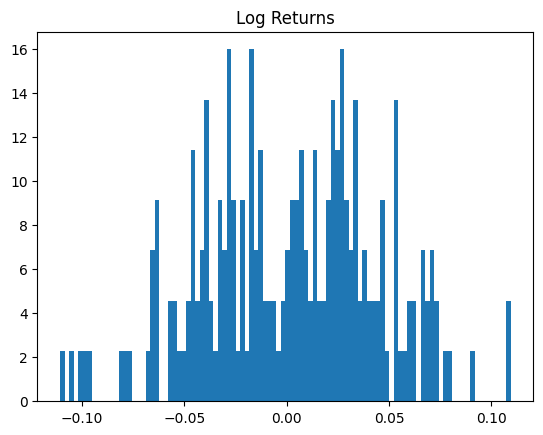

In [10]:
log_prices, moving_average, fundamental_log_prices = chiarella(200, 1, 0.015, 0.015, 36.7, 1/7, 0.043, 0.018, 4.42, 4.42)
log_returns = np.diff(log_prices, axis=0)
plt.hist(log_returns, bins=100, density=True)
plt.title("Log Returns")
plt.show()

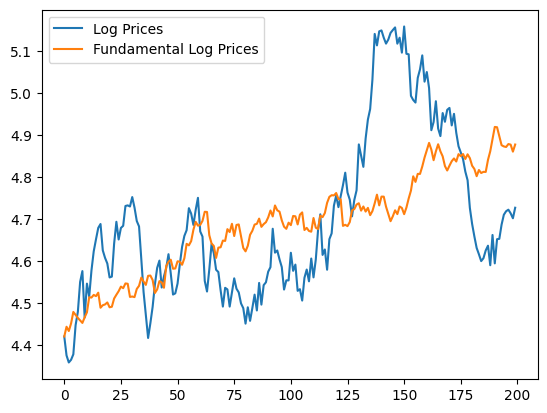

In [11]:
plt.plot(log_prices)
plt.plot(fundamental_log_prices)
plt.legend(["Log Prices", "Fundamental Log Prices"])
plt.show()

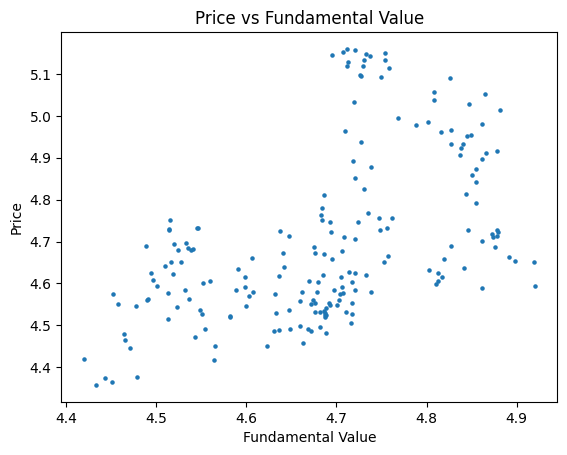

In [12]:
plt.scatter(fundamental_log_prices, log_prices, s=5)
plt.xlabel("Fundamental Value")
plt.ylabel("Price")
plt.title("Price vs Fundamental Value")
plt.show()

As the fundamental value goes up so does the market price